In [198]:
import pandas as pd
import numpy as np
from mist.utils import parse_spectra_mgf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import pickle as pkl
from sklearn.metrics.pairwise import cosine_similarity
from mist.utils.plot_utils import *
import mist.utils as utils

from rdkit.Chem import MolFromSmiles, MolToInchiKey
from rdkit.Chem.Draw import ShowMol
FS = 15
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 
                                   'Bitstream Vera Sans', 'sans-serif']
plt.rcParams.update({'font.size': FS})

In [199]:
fname = '../data/neims/mist/df_neims_canopus_3_8_18.pkl'
df_neims = pd.read_pickle(fname)
df_neims['inchikey'] = df_neims['SMILES'].apply(lambda x: MolToInchiKey(MolFromSmiles(x)))
smiles = df_neims['SMILES'].values
df_neims['spec'].loc[0].shape
specs = []
for spec in df_neims['spec'].values:
    specs.append(spec.astype(np.float32))
df_neims['spec'] = specs

In [200]:
df_neims = df_neims.drop_duplicates(subset='inchikey')

In [201]:
df_neims

,SMILES,spec,inchikey
0,CCC(=O)CCCCCC1NC(=O)C2CCCCN2C(=O)C(Cc2ccccc2)N...,"[[28.0, 9.0], [30.0, 3.0], [32.0, 55.0], [36.0...",DEUCVOIWOGPZGS-UHFFFAOYSA-N
1,CCCCCCCCCCCCCC(=O)NC(C)(C)C(=O)N1CCCC1C(=O)NC(...,"[[28.0, 7.0], [30.0, 54.0], [39.0, 16.0], [43....",VCAGNEUDNVLWPT-UHFFFAOYSA-N
2,CC(C)CC1NC(=O)C(NC(=O)c2ncccc2O)C(C)OC(=O)C(c2...,"[[30.0, 43.0], [39.0, 338.0], [40.0, 159.0], [...",SATIISJKSAELDC-UHFFFAOYSA-N
3,COc1cc(C2C3(O)C(O)C4CC2(O)C(O)(C(=O)O4)C3C(=O)...,"[[25.0, 1.0], [26.0, 30.0], [27.0, 65.0], [28....",CTBBEXWJRAPJIZ-UHFFFAOYSA-N
4,COC1C=COC2(C)Oc3c(C)c(O)c4c(c3C2=O)C(=O)C=C(NC...,"[[25.0, 9.0], [30.0, 21.0], [32.0, 15.0], [33....",BTVYFIMKUHNOBZ-UHFFFAOYSA-N
...,...,...,...
2196,COc1cc2ccc(=O)oc2cc1OC1OC(COC2OC(C)C(OC(C)=O)C...,"[[41.0, 35.0], [42.0, 1.0], [43.0, 261.0], [44...",SRRSXTUHQTVABO-UHFFFAOYSA-N
2197,COc1ccc(-c2oc3cc(O)ccc3c(=O)c2O)cc1OC,"[[15.0, 29.0], [26.0, 17.0], [27.0, 44.0], [28...",LTSJJOKAWSCMBC-UHFFFAOYSA-N
2200,CCOc1ccc2oc(=O)c(-c3ccc(O)cc3)c(C)c2c1,"[[0.0, 0.0], [14.0, 12.0], [15.0, 47.0], [16.0...",MOBDZHABRVPJCH-UHFFFAOYSA-N
2202,Cc1cn(C2OC(CO)C(O)C2O)c(=O)nc1N,"[[14.0, 38.0], [15.0, 122.0], [16.0, 32.0], [1...",ZAYHVCMSTBRABG-UHFFFAOYSA-N


In [202]:
specs_canopus = parse_spectra_mgf('../data/paired_spectra/canopus_train/canopus_hplus_100_all_test.mgf')

4412it [00:02, 1560.04it/s]


In [203]:
specs_canopus[0][0]['SMILES']

'COC1=CC(=O)OC(=C1)C2C3(CC4C(C2(C(C3(C(=O)O4)O)C(=O)C5=CC=CC=C5)O)O)O'

In [204]:
smiles_can = []
specs_can = []
for i in range(len(specs_canopus)):
    smi = specs_canopus[i][0]['SMILES']
    spec = specs_canopus[i][1][0][1]
    specs_can.append(spec)
    smiles_can.append(smi)

In [205]:
print(len(smiles_can))

2206


In [206]:
inchis_can = [MolToInchiKey(MolFromSmiles(smi)) for smi in smiles_can]
inchis = [MolToInchiKey(MolFromSmiles(smi)) for smi in smiles]

In [207]:
df_canopus = pd.DataFrame()
df_canopus['SMILES'] = smiles_can
df_canopus['inchikey'] = inchis_can
df_canopus['spec'] = specs_can

In [208]:
df_canopus = df_canopus.drop_duplicates(subset='inchikey')
df_canopus.index = df_canopus['inchikey']
df_canopus = df_canopus.drop(columns=['inchikey'])
df_canopus

,SMILES,spec
inchikey,,
CTBBEXWJRAPJIZ-UHFFFAOYSA-N,COC1=CC(=O)OC(=C1)C2C3(CC4C(C2(C(C3(C(=O)O4)O)...,"[[51.023438, 952.8703], [51.09034, 24.669291],..."
BTVYFIMKUHNOBZ-UHFFFAOYSA-N,CC1C=CC=C(C(=O)NC2=CC(=O)C3=C(C2=O)C(=C(C4=C3C...,"[[103.054176, 18.04487], [105.070381, 295.5061..."
JYGXADMDTFJGBT-UHFFFAOYSA-N,CC12CCC(=O)C=C1CCC3C2C(CC4(C3CCC4(C(=O)CO)O)C)O,"[[103.039375, 120.379204], [105.068596, 60.008..."
XUBOMFCQGDBHNK-UHFFFAOYSA-N,CC1CN(CCN1)C2=C(C=C3C(=C2OC)N(C=C(C3=O)C(=O)O)...,"[[102.388382, 7.848077], [106.028358, 8.2], [1..."
PMXMIIMHBWHSKN-UHFFFAOYSA-N,CC1=C(C(=O)N2CCCC(C2=N1)O)CCN3CCC(CC3)C4=NOC5=...,"[[110.041367, 151.371994], [110.060173, 2060.7..."
...,...,...
NNJPGOLRFBJNIW-UHFFFAOYSA-N,CNC1CCC2=CC(=C(C(=C2C3=CC=C(C(=O)C=C13)OC)OC)O...,"[[250.0969, 20.0], [256.1005, 22.0], [267.1031..."
ISQRJFLLIDGZEP-UHFFFAOYSA-N,C1=CC(=CC=C1C2=COC3=CC(=CC(=C3C2=O)O)O)OC4C(C(...,"[[153.016, 61.0], [215.0728, 46.0], [243.066, ..."
XHSQDZXAVJRBMX-UHFFFAOYSA-N,C1=C2C(=CC(=C1Cl)Cl)N(C=N2)C3C(C(C(O3)CO)O)O,"[[123.994, 36.0], [151.0035, 112.0], [152.0136..."


In [209]:
merged = pd.merge(df_canopus, df_neims, on='inchikey')

In [220]:
def bin_spectrum(spectrum, bin_width, min_mz=0, max_mz=1000):
    bins = np.arange(min_mz, max_mz + bin_width, bin_width)
    binned = np.zeros_like(bins[:-1])
    for mz, intensity in spectrum:
        idx = int((mz - min_mz) // bin_width)
        if 0 <= idx < len(binned):
            binned[idx] += intensity
    return binned

def compute_cosine_similarity(row, bin_width=5.0):
    spec1 = bin_spectrum(row['spec_x'], bin_width)
    spec2 = bin_spectrum(row['spec_y'], bin_width)
    return cosine_similarity([spec1], [spec2])[0, 0]

In [221]:
merged['cosine_sim'] = merged.apply(compute_cosine_similarity, axis=1)
merged

,inchikey,SMILES_x,spec_x,SMILES_y,spec_y,cosine_sim,tanimoto_sim
0,CTBBEXWJRAPJIZ-UHFFFAOYSA-N,COC1=CC(=O)OC(=C1)C2C3(CC4C(C2(C(C3(C(=O)O4)O)...,"[[51.023438, 952.8703], [51.09034, 24.669291],...",COc1cc(C2C3(O)C(O)C4CC2(O)C(O)(C(=O)O4)C3C(=O)...,"[[25.0, 1.0], [26.0, 30.0], [27.0, 65.0], [28....",0.736854,0.445545
1,BTVYFIMKUHNOBZ-UHFFFAOYSA-N,CC1C=CC=C(C(=O)NC2=CC(=O)C3=C(C2=O)C(=C(C4=C3C...,"[[103.054176, 18.04487], [105.070381, 295.5061...",COC1C=COC2(C)Oc3c(C)c(O)c4c(c3C2=O)C(=O)C=C(NC...,"[[25.0, 9.0], [30.0, 21.0], [32.0, 15.0], [33....",0.445253,0.428218
2,JYGXADMDTFJGBT-UHFFFAOYSA-N,CC12CCC(=O)C=C1CCC3C2C(CC4(C3CCC4(C(=O)CO)O)C)O,"[[103.039375, 120.379204], [105.068596, 60.008...",CC12CCC(=O)C=C1CCC1C2C(O)CC2(C)C1CCC2(O)C(=O)CO,"[[17.0, 5.0], [18.0, 10.0], [28.0, 4.0], [39.0...",0.189754,0.336879
3,XUBOMFCQGDBHNK-UHFFFAOYSA-N,CC1CN(CCN1)C2=C(C=C3C(=C2OC)N(C=C(C3=O)C(=O)O)...,"[[102.388382, 7.848077], [106.028358, 8.2], [1...",COc1c(N2CCNC(C)C2)c(F)cc2c(=O)c(C(=O)O)cn(C3CC...,"[[33.0, 69.0], [34.0, 38.0], [36.0, 52.0], [39...",0.336818,0.410405
4,PMXMIIMHBWHSKN-UHFFFAOYSA-N,CC1=C(C(=O)N2CCCC(C2=N1)O)CCN3CCC(CC3)C4=NOC5=...,"[[110.041367, 151.371994], [110.060173, 2060.7...",Cc1nc2n(c(=O)c1CCN1CCC(c3noc4cc(F)ccc34)CC1)CC...,"[[33.0, 53.0], [34.0, 22.0], [39.0, 119.0], [4...",0.078333,0.060000
...,...,...,...,...,...,...,...
1931,NNJPGOLRFBJNIW-UHFFFAOYSA-N,CNC1CCC2=CC(=C(C(=C2C3=CC=C(C(=O)C=C13)OC)OC)O...,"[[250.0969, 20.0], [256.1005, 22.0], [267.1031...",CNC1CCc2cc(OC)c(OC)c(OC)c2-c2ccc(OC)c(=O)cc21,"[[14.0, 0.0], [15.0, 34.0], [33.0, 7.0], [39.0...",0.272406,0.121324
1932,ISQRJFLLIDGZEP-UHFFFAOYSA-N,C1=CC(=CC=C1C2=COC3=CC(=CC(=C3C2=O)O)O)OC4C(C(...,"[[153.016, 61.0], [215.0728, 46.0], [243.066, ...",O=c1c(-c2ccc(OC3OC(CO)C(O)C(O)C3O)cc2)coc2cc(O...,"[[17.0, 29.0], [18.0, 62.0], [19.0, 5.0], [25....",0.517634,0.020725
1933,XHSQDZXAVJRBMX-UHFFFAOYSA-N,C1=C2C(=CC(=C1Cl)Cl)N(C=N2)C3C(C(C(O3)CO)O)O,"[[123.994, 36.0], [151.0035, 112.0], [152.0136...",OCC1OC(n2cnc3cc(Cl)c(Cl)cc32)C(O)C1O,"[[17.0, 9.0], [18.0, 41.0], [19.0, 44.0], [25....",0.357799,0.023810
1934,ZAYHVCMSTBRABG-UHFFFAOYSA-N,CC1=CN(C(=O)N=C1N)C2C(C(C(O2)CO)O)O,"[[108.0565, 179.0], [109.0392, 270.0], [115.03...",Cc1cn(C2OC(CO)C(O)C2O)c(=O)nc1N,"[[14.0, 38.0], [15.0, 122.0], [16.0, 32.0], [1...",0.383911,0.044304


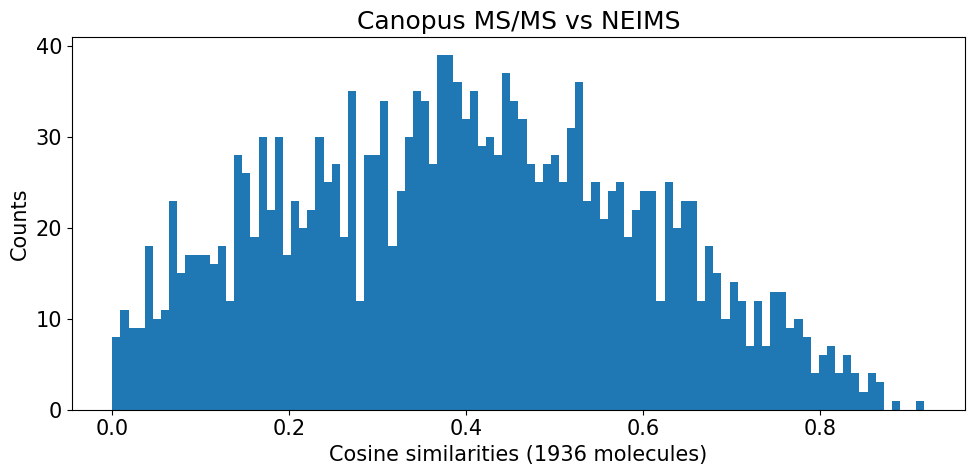

In [222]:
similarities = merged['cosine_sim'].values
plt.figure(figsize=(10,5))
plt.hist(similarities, bins=100)
plt.title('Canopus MS/MS vs NEIMS')
plt.xlabel(f'Cosine similarities ({len(merged)} molecules)')
plt.ylabel('Counts')
plt.tight_layout()
plt.show()

In [224]:
def binarize_spectrum(spectrum, bin_width, min_mz=0, max_mz=1000):
    bins = np.arange(min_mz, max_mz + bin_width, bin_width)
    binned = np.zeros(len(bins) - 1, dtype=int)
    for mz, _ in spectrum:
        idx = int((mz - min_mz) // bin_width)
        if 0 <= idx < len(binned):
            binned[idx] = 1
    return binned

def tanimoto_similarity_binary(row, bin_width=5.0):
    spec1 = binarize_spectrum(row['spec_x'], bin_width)
    spec2 = binarize_spectrum(row['spec_y'], bin_width)
    intersection = np.sum(spec1 & spec2)
    union = np.sum(spec1 | spec2)
    return intersection / union if union != 0 else 0.0

In [225]:
merged['tanimoto_sim'] = merged.apply(tanimoto_similarity_binary, axis=1)
merged

,inchikey,SMILES_x,spec_x,SMILES_y,spec_y,cosine_sim,tanimoto_sim
0,CTBBEXWJRAPJIZ-UHFFFAOYSA-N,COC1=CC(=O)OC(=C1)C2C3(CC4C(C2(C(C3(C(=O)O4)O)...,"[[51.023438, 952.8703], [51.09034, 24.669291],...",COc1cc(C2C3(O)C(O)C4CC2(O)C(O)(C(=O)O4)C3C(=O)...,"[[25.0, 1.0], [26.0, 30.0], [27.0, 65.0], [28....",0.736854,0.680000
1,BTVYFIMKUHNOBZ-UHFFFAOYSA-N,CC1C=CC=C(C(=O)NC2=CC(=O)C3=C(C2=O)C(=C(C4=C3C...,"[[103.054176, 18.04487], [105.070381, 295.5061...",COC1C=COC2(C)Oc3c(C)c(O)c4c(c3C2=O)C(=O)C=C(NC...,"[[25.0, 9.0], [30.0, 21.0], [32.0, 15.0], [33....",0.445253,0.558559
2,JYGXADMDTFJGBT-UHFFFAOYSA-N,CC12CCC(=O)C=C1CCC3C2C(CC4(C3CCC4(C(=O)CO)O)C)O,"[[103.039375, 120.379204], [105.068596, 60.008...",CC12CCC(=O)C=C1CCC1C2C(O)CC2(C)C1CCC2(O)C(=O)CO,"[[17.0, 5.0], [18.0, 10.0], [28.0, 4.0], [39.0...",0.189754,0.716418
3,XUBOMFCQGDBHNK-UHFFFAOYSA-N,CC1CN(CCN1)C2=C(C=C3C(=C2OC)N(C=C(C3=O)C(=O)O)...,"[[102.388382, 7.848077], [106.028358, 8.2], [1...",COc1c(N2CCNC(C)C2)c(F)cc2c(=O)c(C(=O)O)cn(C3CC...,"[[33.0, 69.0], [34.0, 38.0], [36.0, 52.0], [39...",0.336818,0.600000
4,PMXMIIMHBWHSKN-UHFFFAOYSA-N,CC1=C(C(=O)N2CCCC(C2=N1)O)CCN3CCC(CC3)C4=NOC5=...,"[[110.041367, 151.371994], [110.060173, 2060.7...",Cc1nc2n(c(=O)c1CCN1CCC(c3noc4cc(F)ccc34)CC1)CC...,"[[33.0, 53.0], [34.0, 22.0], [39.0, 119.0], [4...",0.078333,0.169811
...,...,...,...,...,...,...,...
1931,NNJPGOLRFBJNIW-UHFFFAOYSA-N,CNC1CCC2=CC(=C(C(=C2C3=CC=C(C(=O)C=C13)OC)OC)O...,"[[250.0969, 20.0], [256.1005, 22.0], [267.1031...",CNC1CCc2cc(OC)c(OC)c(OC)c2-c2ccc(OC)c(=O)cc21,"[[14.0, 0.0], [15.0, 34.0], [33.0, 7.0], [39.0...",0.272406,0.268657
1932,ISQRJFLLIDGZEP-UHFFFAOYSA-N,C1=CC(=CC=C1C2=COC3=CC(=CC(=C3C2=O)O)O)OC4C(C(...,"[[153.016, 61.0], [215.0728, 46.0], [243.066, ...",O=c1c(-c2ccc(OC3OC(CO)C(O)C(O)C3O)cc2)coc2cc(O...,"[[17.0, 29.0], [18.0, 62.0], [19.0, 5.0], [25....",0.517634,0.094340
1933,XHSQDZXAVJRBMX-UHFFFAOYSA-N,C1=C2C(=CC(=C1Cl)Cl)N(C=N2)C3C(C(C(O3)CO)O)O,"[[123.994, 36.0], [151.0035, 112.0], [152.0136...",OCC1OC(n2cnc3cc(Cl)c(Cl)cc32)C(O)C1O,"[[17.0, 9.0], [18.0, 41.0], [19.0, 44.0], [25....",0.357799,0.060000
1934,ZAYHVCMSTBRABG-UHFFFAOYSA-N,CC1=CN(C(=O)N=C1N)C2C(C(C(O2)CO)O)O,"[[108.0565, 179.0], [109.0392, 270.0], [115.03...",Cc1cn(C2OC(CO)C(O)C2O)c(=O)nc1N,"[[14.0, 38.0], [15.0, 122.0], [16.0, 32.0], [1...",0.383911,0.142857


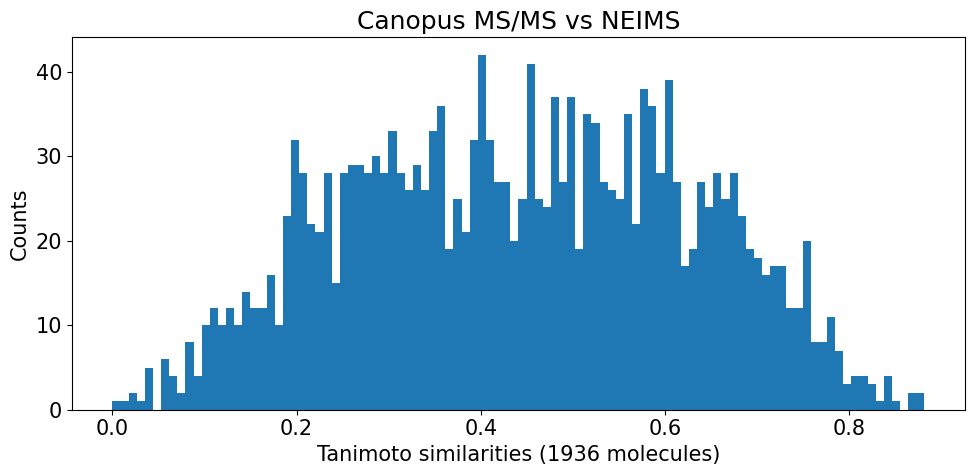

In [226]:
similarities = merged['tanimoto_sim'].values
plt.figure(figsize=(10,5))
plt.hist(similarities, bins=100)
plt.title('Canopus MS/MS vs NEIMS')
plt.xlabel(f'Tanimoto similarities ({len(merged)} molecules)')
plt.ylabel('Counts')
plt.tight_layout()
plt.show()